# Galaxy Clustering Algorithm!

- Use VFS galaxies! Fortunately, I have not deleted my catalog of galaxies...
- What data?
    - Maybe feed in either CIGALE or GALFIT output parameters?
    - Measure curves of growth??
- Use PCA for dimensionality reduction
- Then...UNSUPERVISED LEARNING! I.E., find natural groupings in the data without pre-defined labels
- And then...interpret. Is there any physical meaning associated with the clusters?
    - Morphology? 
        - May have to perform some visual inspection
        - Could also try statmorph?
    - Environment?
        - vf_v2_environment.fits flags

### To begin, I will need some features
- A few thoughts:
    - NUV-r, FUV-NUV, W1-W3, g-r, W1-W2 colors
    - CIGALE sSFR, Mstar, A_V
    - GALFIT nser (W1), nser (W3), axis ratio (W1), size ratio (W3/W1)
    - W1 luminosity
- Will have to 'standardize' these features for clustering
    - ensures all features contribute equally regardless of their original units and scales

---

## K-means Run

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#from galfit_kmeans import galfit_kmeans
from kmeans_pipeline import run_kmeans

import warnings
warnings.filterwarnings("ignore")

#set colors=False to use the default GALFIT set of features (Sersic index, effective radius)
#df_scaled = galfit_kmeans(colors=False)

#colors=True will include the following color magnitudes from JM's SGA2020 photometry:
    # NUV-r
    # W1-W3

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
'CN_W2', 'CN_W3-fixBA']

##############################################################
Removed 4785/6780 galaxies with GALFIT and PHOT quality flags.
##############################################################
IQR clipping (k=1.5): Removing an additional 570/1995 outliers (28.6%)
Remaining galaxies: 1425


A copy of unscaled/scaled galaxy features was written to data/kmeans_feature_data.csv!

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/kmeans_median_features.csv:

##################################################################
Using default layout dictionary for median group feature subplots!
##################################################################


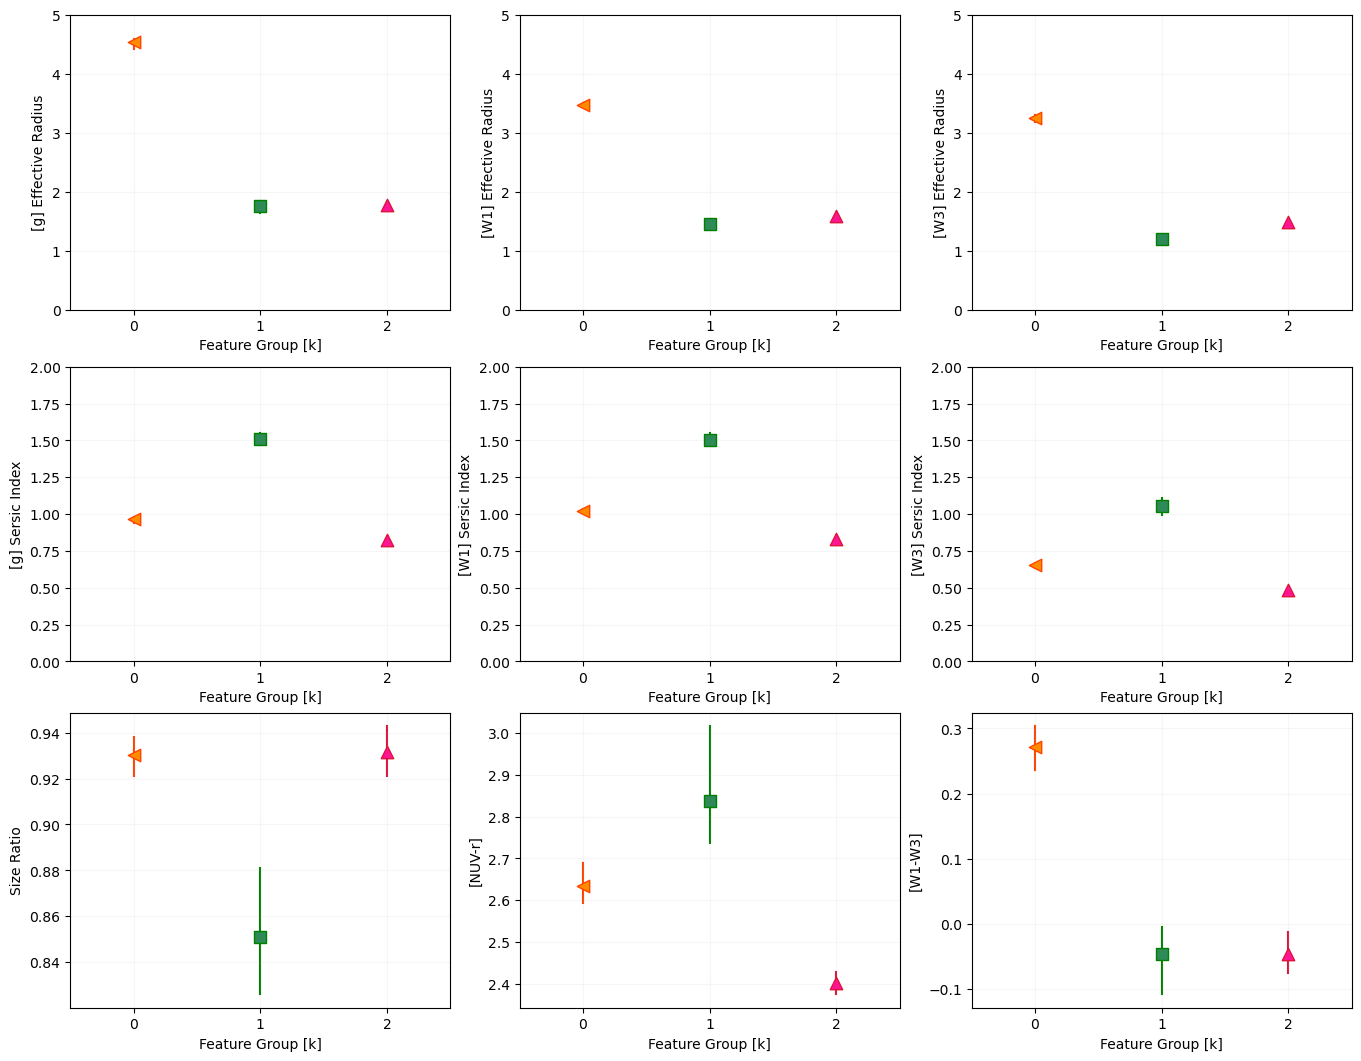

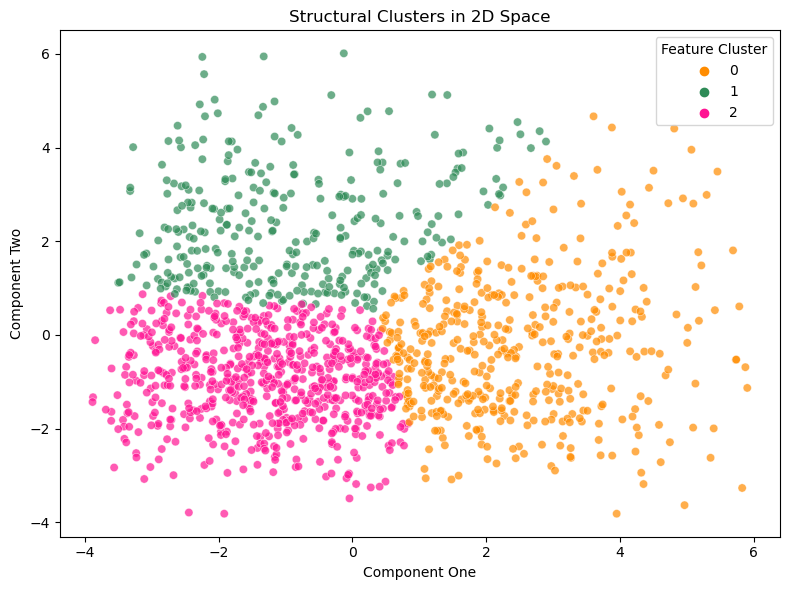

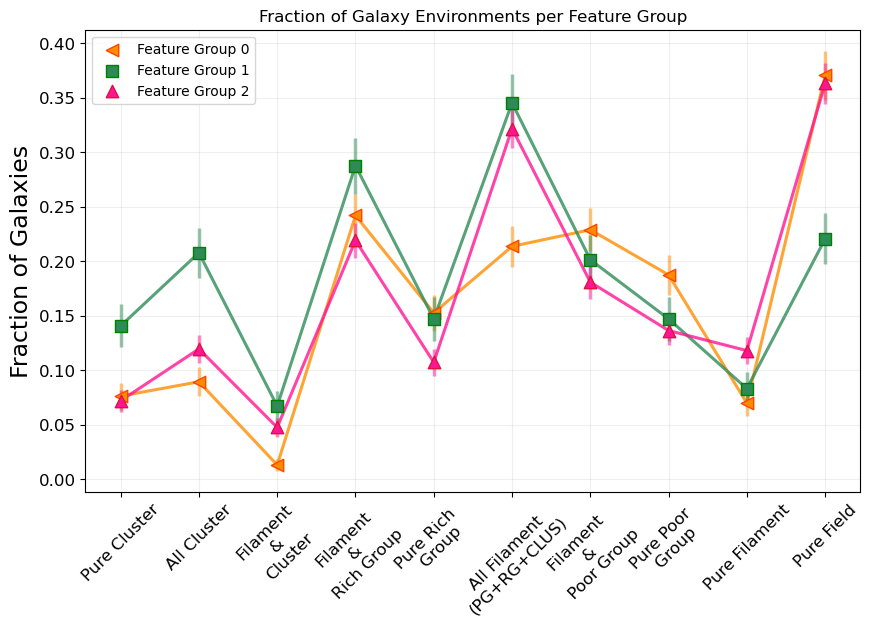

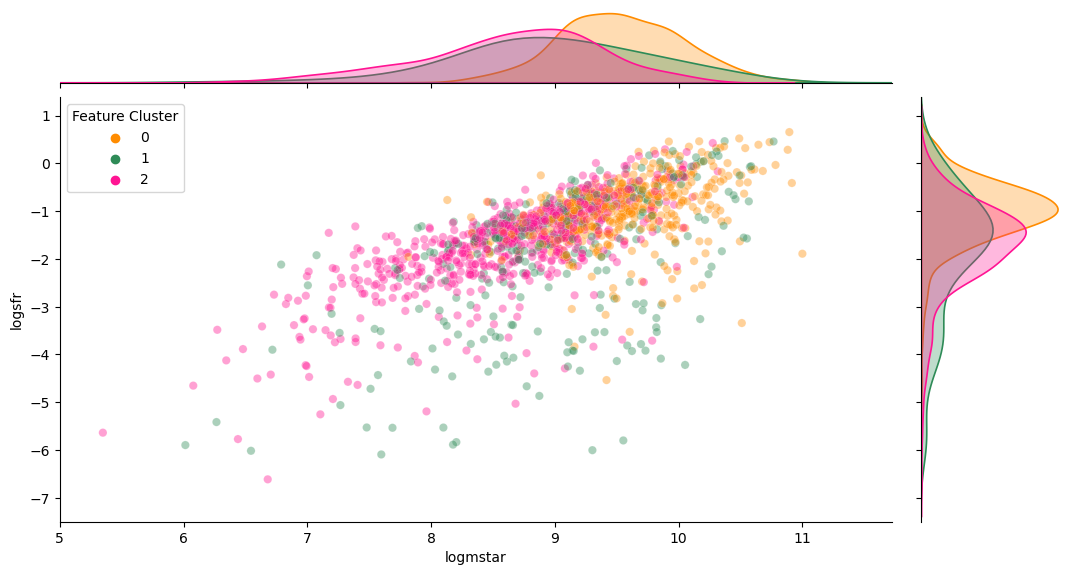

In [4]:
df = run_kmeans(colors=False)

## HDBSCAN Run

In [16]:
from hdbscan_pipeline import run_hdbscan

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
'CN_W2', 'CN_W3-fixBA']

##############################################################
Removed 4785/6780 galaxies with GALFIT and PHOT quality flags.
##############################################################


A copy of the scaled galaxy features was written to data/hdb_feature_data.csv!

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/hdbscan_median_features.csv:

##################################################################
Using default layout dictionary for median group feature subplots!
##################################################################


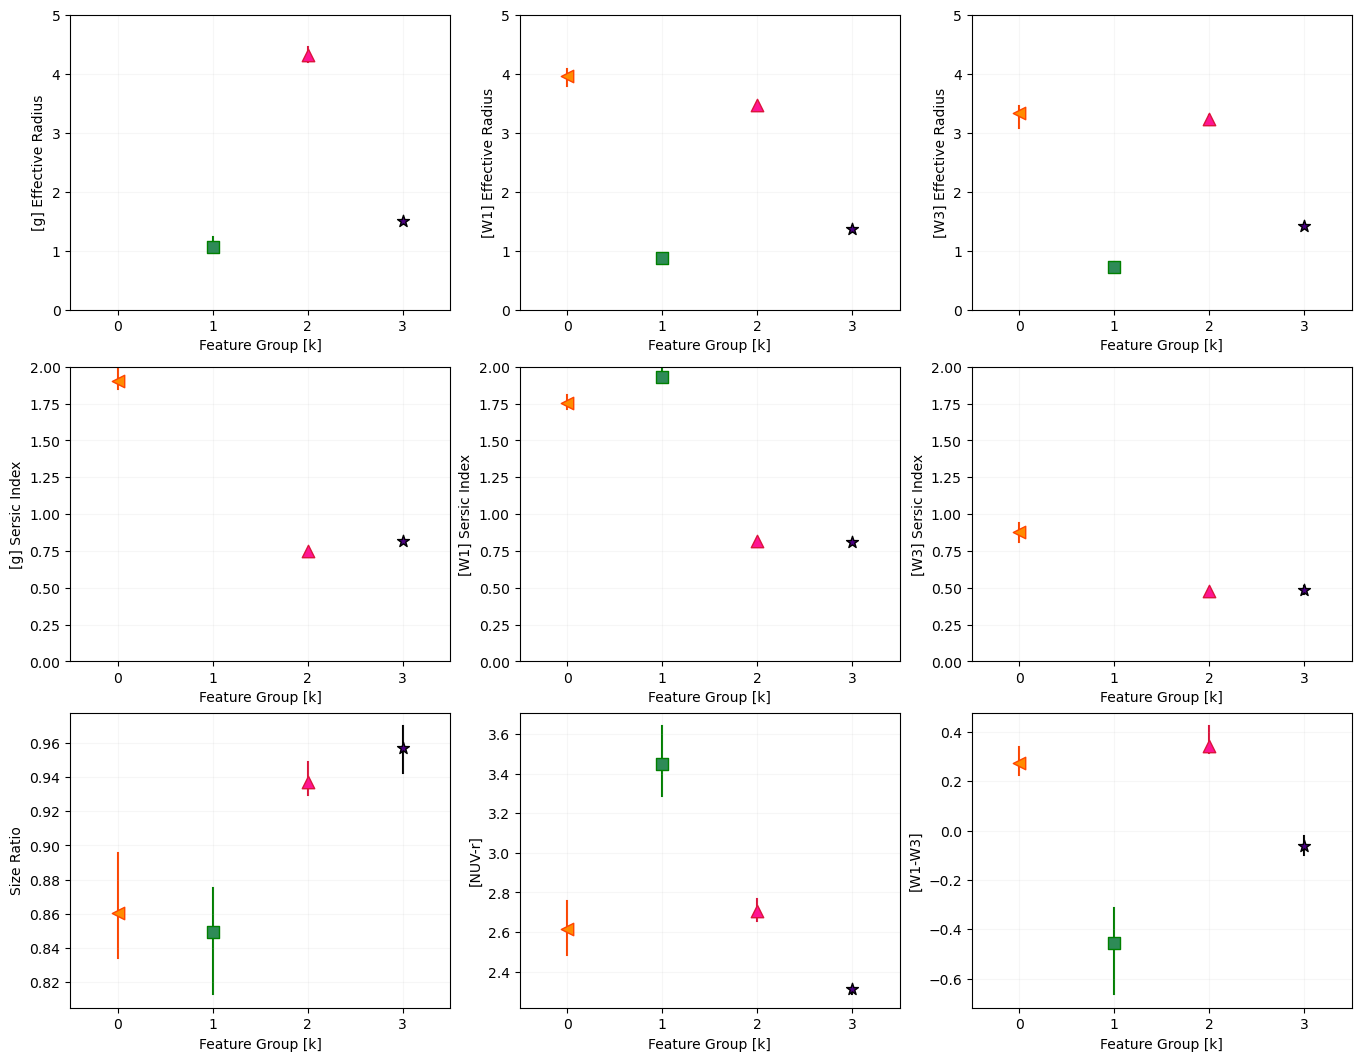

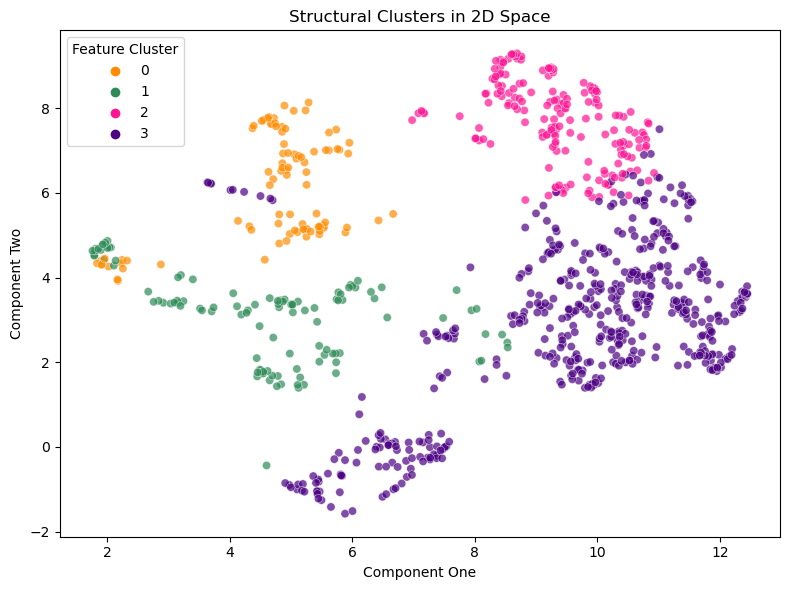

Environment 0 cluster 0: fraction 0.133+/-0.036
Environment 0 cluster 1: fraction 0.263+/-0.041
Environment 0 cluster 2: fraction 0.101+/-0.023
Environment 0 cluster 3: fraction 0.137+/-0.015
Environment 1 cluster 0: fraction 0.378+/-0.051
Environment 1 cluster 1: fraction 0.289+/-0.042
Environment 1 cluster 2: fraction 0.253+/-0.033
Environment 1 cluster 3: fraction 0.213+/-0.018
Environment 2 cluster 0: fraction 0.267+/-0.047
Environment 2 cluster 1: fraction 0.140+/-0.033
Environment 2 cluster 2: fraction 0.225+/-0.031
Environment 2 cluster 3: fraction 0.165+/-0.017
Environment 3 cluster 0: fraction 0.311+/-0.049
Environment 3 cluster 1: fraction 0.342+/-0.044
Environment 3 cluster 2: fraction 0.180+/-0.029
Environment 3 cluster 3: fraction 0.350+/-0.021
Environment 4 cluster 0: fraction 0.167+/-0.039
Environment 4 cluster 1: fraction 0.202+/-0.038
Environment 4 cluster 2: fraction 0.365+/-0.036
Environment 4 cluster 3: fraction 0.354+/-0.021


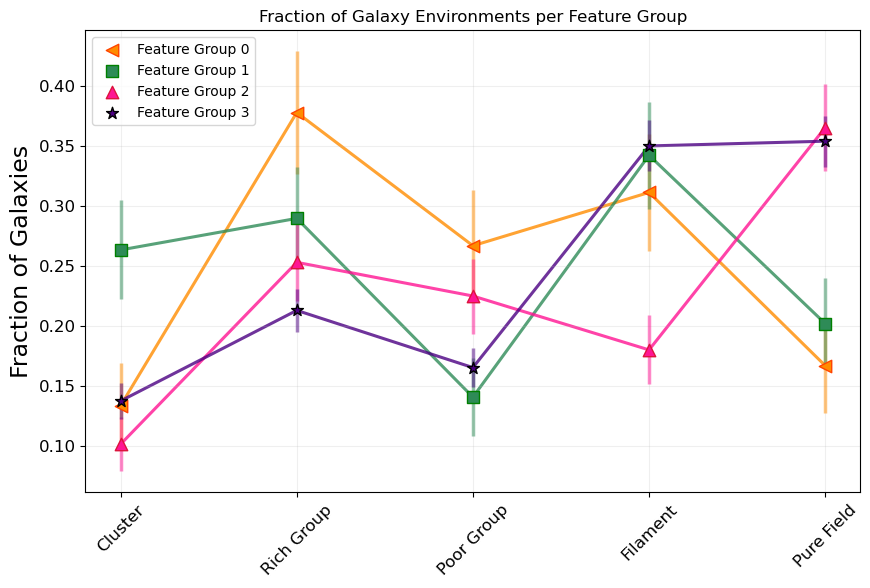

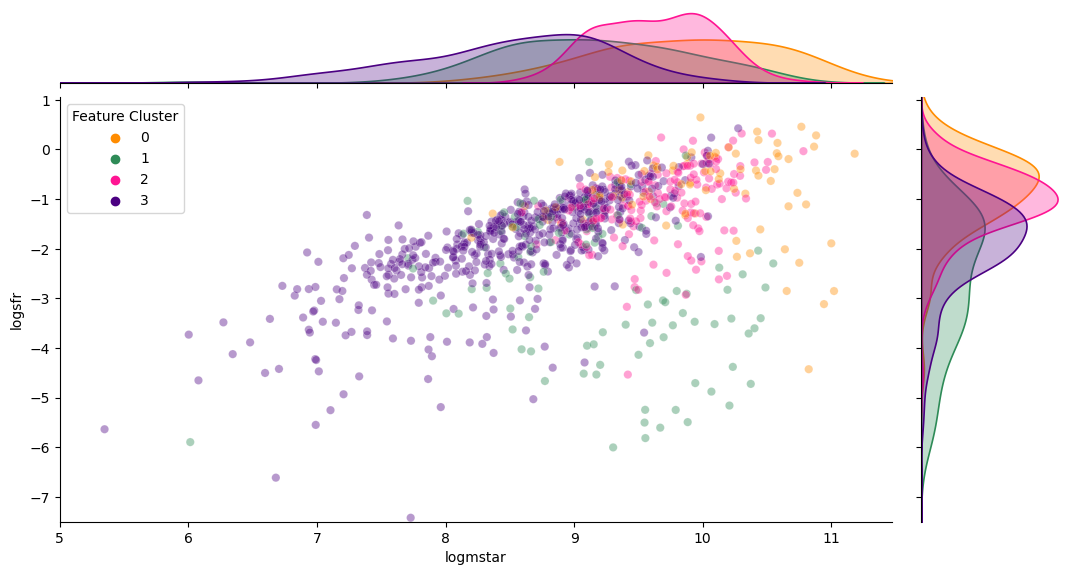

In [17]:
import warnings
warnings.filterwarnings("ignore")

df_scaled = run_hdbscan(colors=False)

## Testbed

In [35]:
import sys
sys.path.insert(0,'utils')
from clustering_utils import run1_hdbscan, umap_2d, find_optimal_hdbparams
from plotting_utils import plot_clusters, plot_corner, plot_env_fraction, plot_group_features, plot_sfrmstar

import warnings
warnings.filterwarnings("ignore")

In [21]:
import pandas as pd
df_scaled = pd.read_csv('data/hdb_feature_data.csv')
#features=['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
#          'CN_W2', 'CN_W3-fixBA']
features=['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
         'CN_W2', 'CN_W3-fixBA']

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
best=find_optimal_hdbparams(df_scaled, features,
                           min_cluster_sizes=[20,30,40,50,60,100],
                           min_samples_list=[10,15,20,30,50,60,100,'same'],
                           metrics=['euclidean', 'manhattan', 'canberra'],
                           cluster_methods=['eom','leaf'])

HDBSCAN DBCV sweep:   0%|          | 0/288 [00:00<?, ?it/s]

############################
 Best parameters (DBCV):
   min_cluster_size         = 20
   min_samples              = 10
   metric                   = canberra
   cluster_selection_method = leaf
   DBCV score               = -0.147
############################


In [ ]:
min_cluster_size = best[0]
min_samples = best[1]
metric = best[2]
cluster_selection_method = best[3]

In [32]:
#perform HDBSCAN on the full set of features, using the parameters defined above.

feature_data = run1_hdbscan(df_scaled, features, min_cluster_size=80, min_samples=3,
                           metric='canberra', cluster_selection_method='eom')

#feature_data = run1_hdbscan(df_scaled, features, min_cluster_size=min_cluster_size, min_samples=min_samples,
#                           metric=metric, cluster_selection_method=cluster_selection_method)

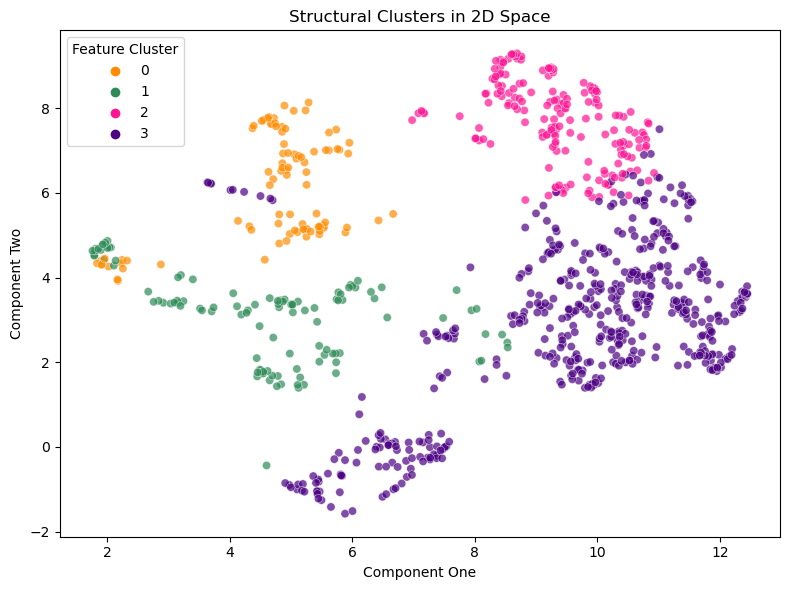

In [33]:
#create the Comp1, Comp2 columns. IGNORES 'Feature Cluster' column!
feature_data_umap = umap_2d(feature_data, features)

#plort.
plot_clusters(feature_data_umap[feature_data['Feature Cluster']!=-1], UMAP=True) #x='CRE_W1-fixBA_unscaled', y='CRE_W3-fixBA_unscaled')

Environment 0 cluster 0: fraction 0.133+/-0.036
Environment 0 cluster 1: fraction 0.263+/-0.041
Environment 0 cluster 2: fraction 0.101+/-0.023
Environment 0 cluster 3: fraction 0.137+/-0.015
Environment 1 cluster 0: fraction 0.378+/-0.051
Environment 1 cluster 1: fraction 0.289+/-0.042
Environment 1 cluster 2: fraction 0.253+/-0.033
Environment 1 cluster 3: fraction 0.213+/-0.018
Environment 2 cluster 0: fraction 0.267+/-0.047
Environment 2 cluster 1: fraction 0.140+/-0.033
Environment 2 cluster 2: fraction 0.225+/-0.031
Environment 2 cluster 3: fraction 0.165+/-0.017
Environment 3 cluster 0: fraction 0.311+/-0.049
Environment 3 cluster 1: fraction 0.342+/-0.044
Environment 3 cluster 2: fraction 0.180+/-0.029
Environment 3 cluster 3: fraction 0.350+/-0.021
Environment 4 cluster 0: fraction 0.167+/-0.039
Environment 4 cluster 1: fraction 0.202+/-0.038
Environment 4 cluster 2: fraction 0.365+/-0.036
Environment 4 cluster 3: fraction 0.354+/-0.021


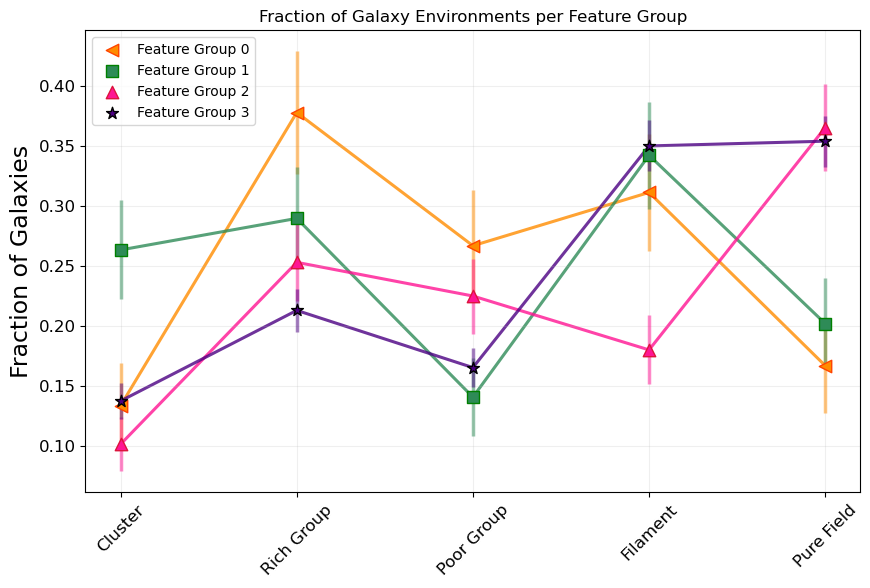

In [24]:
plot_env_fraction(feature_data[feature_data['Feature Cluster']!=-1], main_only=True)

In [26]:
from data_utils import create_median_table
summary_rows = create_median_table(feature_data[feature_data['Feature Cluster']!=-1], features)
cluster_summary = pd.DataFrame(summary_rows)

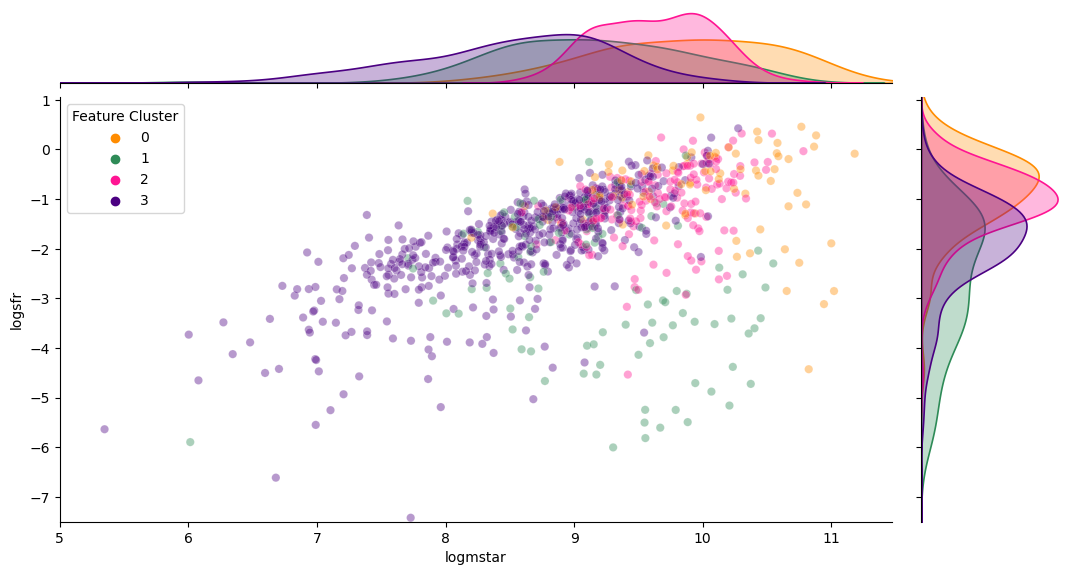

In [36]:
plot_sfrmstar(feature_data[feature_data['Feature Cluster']!=-1])